## Step 1: Import Libraries

In [5]:
# Import libraries for data manipulation
import pandas as pd
import numpy as np

# Import libraries for data visualization
import matplotlib.pyplot as plt

# Import OpenCV for image processing
import cv2

# Import OS module to access dataset files
import os

# Import utilities for splitting dataset and encoding labels
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Import TensorFlow and Keras for building the CNN model
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

## Step 2: Load the Dataset

In [6]:
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        if filename.endswith(".csv"):
            print(os.path.join(dirname, filename))

/kaggle/input/datasets/dhruvildave/english-handwritten-characters-dataset/english.csv


In [7]:
df = pd.read_csv(
    "/kaggle/input/datasets/dhruvildave/english-handwritten-characters-dataset/english.csv"
)

df.head()

,image,label
0,Img/img001-001.png,0
1,Img/img001-002.png,0
2,Img/img001-003.png,0
3,Img/img001-004.png,0
4,Img/img001-005.png,0


## Step 3: Explore the Dataset

In [8]:
# Display the first five rows of the dataset
df.head()

,image,label
0,Img/img001-001.png,0
1,Img/img001-002.png,0
2,Img/img001-003.png,0
3,Img/img001-004.png,0
4,Img/img001-005.png,0


In [9]:
# Display dataset information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3410 entries, 0 to 3409
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   image   3410 non-null   object
 1   label   3410 non-null   object
dtypes: object(2)
memory usage: 53.4+ KB


In [10]:
# Display the number of rows and columns
print("Dataset Shape:", df.shape)

Dataset Shape: (3410, 2)


In [11]:
# Display all column names
print(df.columns)

Index(['image', 'label'], dtype='object')


In [12]:
# Check for missing values
df.isnull().sum()

image    0
label    0
dtype: int64

In [13]:
# Display all unique character labels
print(df["label"].unique())

['0' '1' '2' '3' '4' '5' '6' '7' '8' '9' 'A' 'B' 'C' 'D' 'E' 'F' 'G' 'H'
 'I' 'J' 'K' 'L' 'M' 'N' 'O' 'P' 'Q' 'R' 'S' 'T' 'U' 'V' 'W' 'X' 'Y' 'Z'
 'a' 'b' 'c' 'd' 'e' 'f' 'g' 'h' 'i' 'j' 'k' 'l' 'm' 'n' 'o' 'p' 'q' 'r'
 's' 't' 'u' 'v' 'w' 'x' 'y' 'z']


In [14]:
# Count how many images belong to each character
df["label"].value_counts()

label
0    55
1    55
2    55
3    55
4    55
     ..
v    55
w    55
x    55
y    55
z    55
Name: count, Length: 62, dtype: int64

## Step 4: Display Sample Images

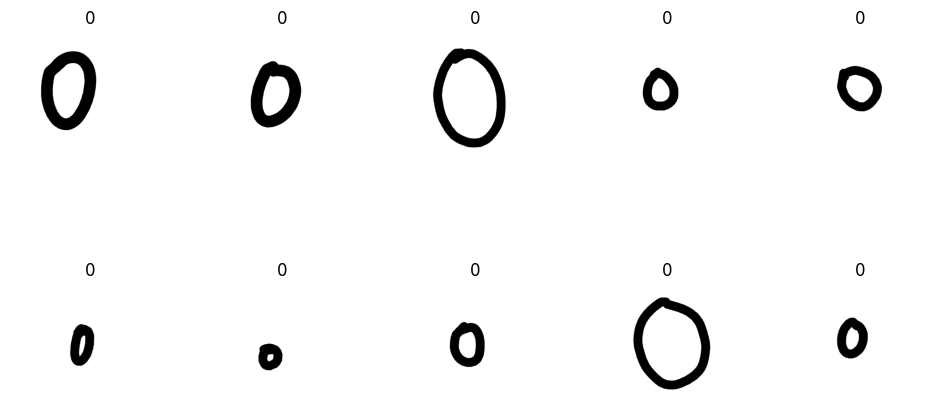

In [15]:
#Before running this, first check your column names. If they are:
#image,label
plt.figure(figsize=(12, 6))

for i in range(10):

    img = cv2.imread("/kaggle/input/datasets/dhruvildave/english-handwritten-characters-dataset/" + df.iloc[i]["image"])

    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.subplot(2,5,i+1)

    plt.imshow(img)

    plt.title(df.iloc[i]["label"])

    plt.axis("off")

plt.show()

## Step 5: Encode the Labels

In [16]:
# Encoding character labels into numerical values for model training
# Create LabelEncoder object
encoder = LabelEncoder()

# Convert character labels into numeric labels
df["label"] = encoder.fit_transform(df["label"])

# Display first few rows
df.head()

,image,label
0,Img/img001-001.png,0
1,Img/img001-002.png,0
2,Img/img001-003.png,0
3,Img/img001-004.png,0
4,Img/img001-005.png,0


## Step 6: Load and Preprocess Images

In [19]:

# Reading, resizing, and normalizing handwritten character images
# Create empty lists to store images and labels
images = []
labels = []

# Base dataset path
base_path = "/kaggle/input/datasets/dhruvildave/english-handwritten-characters-dataset/"

# Loop through each row in the dataset
for index, row in df.iterrows():

    # Complete image path
    img_path = os.path.join(base_path, row["image"])

    # Read image in grayscale
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

    # Resize image
    img = cv2.resize(img, (28, 28))

    # Normalize pixel values
    img = img / 255.0

    # Store image and label
    images.append(img)
    labels.append(row["label"])

## Step 7: Convert Images into NumPy Arrays

In [23]:
# Preparing image data for CNN model
# Convert lists into NumPy arrays
X = np.array(images)
y = np.array(labels)

# Reshape images for CNN input
X = X.reshape(-1, 28, 28, 1)

# Display dataset shape
print("Image Shape:", X.shape)
print("Label Shape:", y.shape)

Image Shape: (3410, 28, 28, 1)
Label Shape: (3410,)


## Step 8: Split the Dataset

In [25]:
# Split the dataset into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Display dataset shapes
print("Training Images:", X_train.shape)
print("Testing Images :", X_test.shape)
print("Training Labels:", y_train.shape)
print("Testing Labels :", y_test.shape)

Training Images: (2728, 28, 28, 1)
Testing Images : (682, 28, 28, 1)
Training Labels: (2728,)
Testing Labels : (682,)


## Step 9: Build the CNN Model

In [30]:
# Build the CNN model

model = Sequential()

# First Convolution Layer
model.add(Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)))

# First Pooling Layer
model.add(MaxPooling2D(pool_size=(2,2)))

# Second Convolution Layer
model.add(Conv2D(64, (3,3), activation='relu'))

# Second Pooling Layer
model.add(MaxPooling2D(pool_size=(2,2)))

# Flatten the feature maps
model.add(Flatten())

# Fully Connected Layer
model.add(Dense(128, activation='relu'))

# Dropout layer to reduce overfitting
model.add(Dropout(0.3))

# Output Layer
model.add(Dense(len(np.unique(y)), activation='softmax'))

# Display model architecture
model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 62)             │         7,998 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 231,742 (905.24 KB)

 Trainable params: 231,742 (905.24 KB)

 Non-trainable params: 0 (0.00 B)

## Step 10: Compile the Model

In [45]:
# Compile the CNN model
#An optimizer helps the model learn from its mistakes.
#The loss function measures how wrong the model's predictions are.
#This tells TensorFlow to display the accuracy after each training epoch.
model.compile(optimizer='adam',
             loss='sparse_categorical_crossentropy',
             metrics=['accuracy'])

## Step 11: Train the Model

In [36]:
history=model.fit(X_train,
                  y_train,
                  epochs=10,
                 batch_size=32,
                 validation_split=0.2)

Epoch 1/10
69/69 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - accuracy: 0.0179 - loss: 4.1279 - val_accuracy: 0.0128 - val_loss: 4.1067
Epoch 2/10
69/69 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.0454 - loss: 3.9875 - val_accuracy: 0.0769 - val_loss: 3.7941
Epoch 3/10
69/69 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.1347 - loss: 3.4738 - val_accuracy: 0.2454 - val_loss: 3.0570
Epoch 4/10
69/69 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.2342 - loss: 2.8899 - val_accuracy: 0.3462 - val_loss: 2.5791
Epoch 5/10
69/69 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.3327 - loss: 2.3908 - val_accuracy: 0.4194 - val_loss: 2.2365
Epoch 6/10
69/69 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.4088 - loss: 2.1314 - val_accuracy: 0.4963 - val_loss: 1.9778
Epoch 7/10
69/69 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.4844 - loss: 1.8253 - val_accuracy: 0.5220 - val_loss: 1.8000
Epoch 8/10
69/69 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - accuracy: 0.5238 - loss: 1.6496 - val_accuracy: 0.5458 - v

## Step 12: Evaluate the Model

In [37]:
# Evaluate the model on the test dataset

loss, accuracy = model.evaluate(X_test, y_test)

print("Test Loss:", loss)
print("Test Accuracy:", accuracy)

22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5953 - loss: 1.4894
Test Loss: 1.489384412765503
Test Accuracy: 0.5953079462051392


## Step 13: Predict Handwritten Characters

In [38]:
# Predict labels for test images

predictions = model.predict(X_test)

predicted_labels = np.argmax(predictions, axis=1)

22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step


## Step 14: Display Predictions

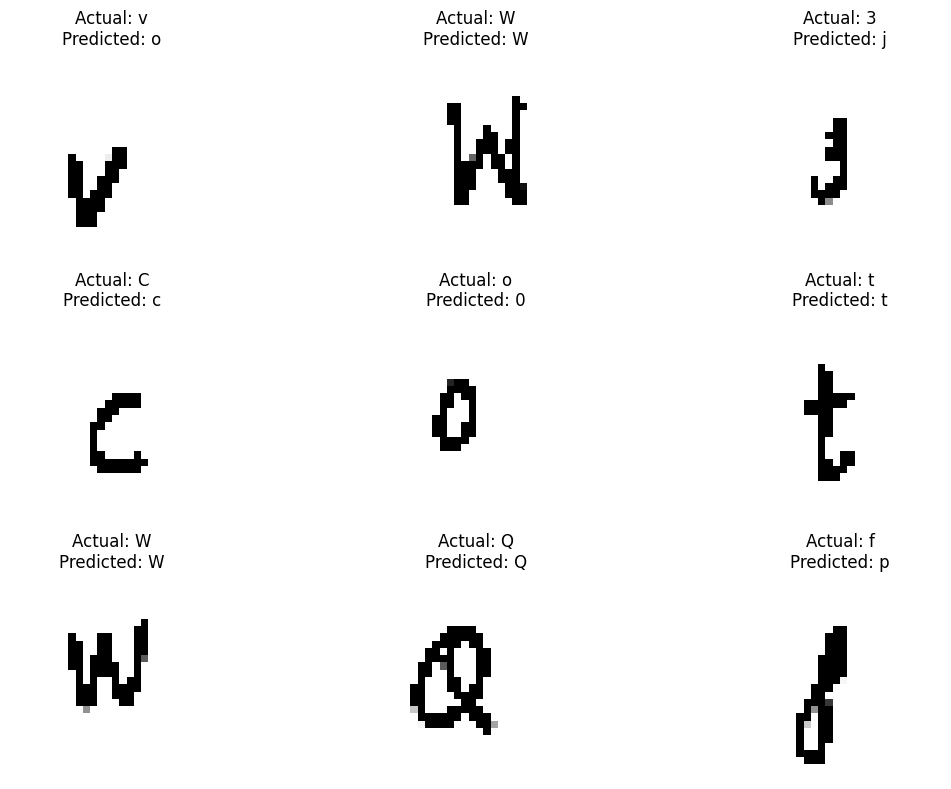

In [39]:
# Display some predictions

plt.figure(figsize=(12,8))

for i in range(9):

    plt.subplot(3,3,i+1)

    plt.imshow(X_test[i].reshape(28,28), cmap='gray')

    actual = encoder.inverse_transform([y_test[i]])[0]
    predicted = encoder.inverse_transform([predicted_labels[i]])[0]

    plt.title(f"Actual: {actual}\nPredicted: {predicted}")

    plt.axis("off")

plt.tight_layout()
plt.show()

## Step 15: Plot Accuracy Graph

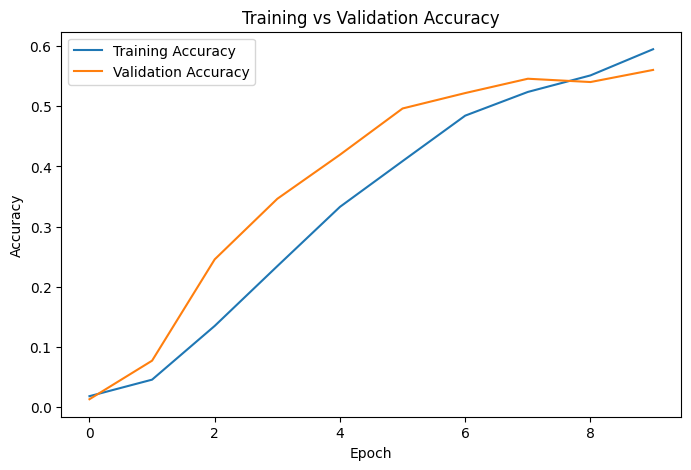

In [40]:
# Plot training and validation accuracy

plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'], label='Training Accuracy')

plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title("Training vs Validation Accuracy")

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.legend()

plt.show()

## Step 16: Plot Loss Graph

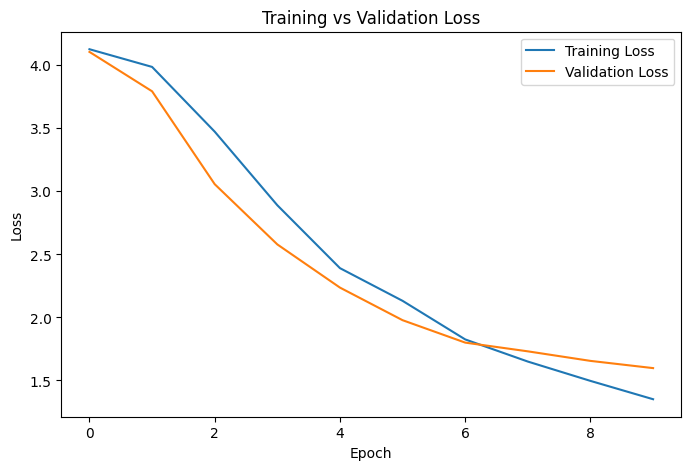

In [41]:
# Plot training and validation loss

plt.figure(figsize=(8,5))

plt.plot(history.history['loss'], label='Training Loss')

plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title("Training vs Validation Loss")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.legend()

plt.show()

## Step 17: Display Character Distribution (Bar Graph)

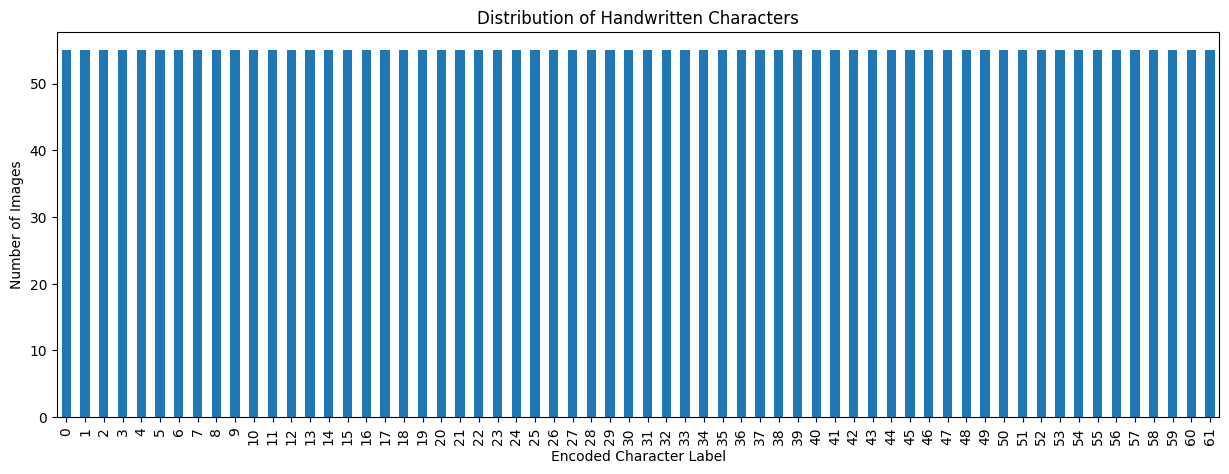

In [42]:
# Plot character distribution

plt.figure(figsize=(15,5))

df["label"].value_counts().sort_index().plot(kind="bar")

plt.title("Distribution of Handwritten Characters")

plt.xlabel("Encoded Character Label")

plt.ylabel("Number of Images")

plt.show()

## Step 18: Save the Model

In [44]:
# Save the trained CNN model

model.save("handwritten_character_cnn.keras")

print("Model saved successfully!")

Model saved successfully!
